In [18]:
import re
import nltk
import string
import fasttext
from nltk import wordnet
from nltk.corpus import stopwords


import numpy as np
import pandas as pd

from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences

from keras.layers import Conv1D, MaxPooling1D, Embedding, Concatenate, Dense, Input, Flatten
from keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

In [19]:
MAX_SEQUENCE_LENGTH = 100
MAX_NB_WORDS = 200000
EMBEDDING_DIM = 100
VALIDATION_SPLIT = 0.2

In [1]:
import pandas as pd
df = pd.read_csv(r"IMDB Dataset.csv")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
data = df.sample(n=20000)

{'negative', 'positive'}

In [23]:
def actual_tag(string):
    if string.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif string.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif string.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif string.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN

In [24]:
def lemmatize(array):
    opt_list = []
    wl = nltk.WordNetLemmatizer()
    stop = stopwords.words('english')
    stop += list(string.punctuation)
    for tple in array:
        word, tag = tple
        if word.lower() not in stop and word.isalpha():
            temp = wl.lemmatize(word,actual_tag(tag))
            opt_list.append(temp.lower())
    return opt_list

In [25]:
def preprocess(text):
    text = nltk.tokenize.word_tokenize(text)
    text = nltk.pos_tag(text)
    text = lemmatize(text)
    return text

In [ ]:
processed_data = data['review'].map(preprocess)

In [ ]:
processed_data.head()

In [ ]:
data['sentiment'].value_counts()

In [ ]:
# Tokenization
tokenizer = Tokenizer(num_words=MAX_NB_WORDS)
tokenizer.fit_on_texts(processed_data)
sequences = tokenizer.texts_to_sequences(processed_data)

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

In [13]:
data.loc[data['sentiment'] == 'positive','sentiment'] = 1
data.loc[data['sentiment'] == 'negative','sentiment'] = 0
labels = np.asarray(data['sentiment']).astype(np.float32)
labels

array([0., 1., 0., ..., 1., 0., 1.], dtype=float32)

In [14]:
features = pad_sequences(sequences, MAX_SEQUENCE_LENGTH)

features.shape, labels.shape

((20000, 100), (20000,))

In [15]:
x_train, x_test, y_train, y_test = train_test_split( features, labels, test_size=0.20, random_state=42)
x_test, x_val, y_test, y_val = train_test_split( features, labels, test_size=0.50, random_state=4)
x_train.shape, y_train.shape

((16000, 100), (16000,))

In [16]:
embedding_model = fasttext.load_model(r"D:\Notebook\Projects\Embedding_Models\fasttext_embedding_model.bin")

embedding_matrix = np.zeros((len(word_index) + 1, EMBEDDING_DIM))
for word, i in word_index.items():
    embedding_vector = embedding_model.get_word_vector(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        
embedding_layer = Embedding(len(word_index) + 1,
                            EMBEDDING_DIM,
                            weights=[embedding_matrix],
                            input_length=MAX_SEQUENCE_LENGTH)

In [17]:

convs = []
filter_sizes = [3,4,5]

sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,))
embedded_sequences = embedding_layer(sequence_input)

for fsz in filter_sizes:
    l_conv = Conv1D(128,fsz,activation='relu')(embedded_sequences)
    l_pool = MaxPooling1D(5)(l_conv)
    convs.append(l_pool)   
l_merge = Concatenate()(convs)
l_cov1= Conv1D(filters=128, kernel_size=5, activation='relu')(l_merge)
l_pool1 = MaxPooling1D(5)(l_cov1)
# l_cov2 = Conv1D(filters=128, kernel_size=5, activation='relu')(l_pool1)
# l_pool2 = MaxPooling1D(30)(l_cov2)
l_flat = Flatten()(l_pool1)
l_dense = Dense(128, activation='relu')(l_flat)
preds = Dense(1, activation='sigmoid')(l_dense)

model = Model(sequence_input, preds)
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 100)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 100, 100)             5904300   ['input_1[0][0]']             
                                                                                                  
 conv1d (Conv1D)             (None, 98, 128)              38528     ['embedding[0][0]']           
                                                                                                  
 conv1d_1 (Conv1D)           (None, 97, 128)              51328     ['embedding[0][0]']           
                                                                                              

In [35]:
history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
          epochs=10, batch_size=150, verbose=1)

Epoch 1/10
107/107 [==============================] - 26s 231ms/step - loss: 0.3014 - acc: 0.8598 - val_loss: 0.1410 - val_acc: 0.9543
Epoch 2/10
107/107 [==============================] - 25s 229ms/step - loss: 0.0676 - acc: 0.9762 - val_loss: 0.1441 - val_acc: 0.9626
Epoch 3/10
107/107 [==============================] - 24s 228ms/step - loss: 0.0174 - acc: 0.9957 - val_loss: 0.1601 - val_acc: 0.9667
Epoch 4/10
107/107 [==============================] - 24s 229ms/step - loss: 0.0041 - acc: 0.9996 - val_loss: 0.1865 - val_acc: 0.9679
Epoch 5/10
107/107 [==============================] - 24s 227ms/step - loss: 7.2571e-04 - acc: 1.0000 - val_loss: 0.2051 - val_acc: 0.9669
Epoch 6/10
107/107 [==============================] - 24s 227ms/step - loss: 2.9376e-04 - acc: 1.0000 - val_loss: 0.2287 - val_acc: 0.9670
Epoch 7/10
107/107 [==============================] - 24s 226ms/step - loss: 1.5814e-04 - acc: 1.0000 - val_loss: 0.2466 - val_acc: 0.9672
Epoch 8/10
107/107 [=======================

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


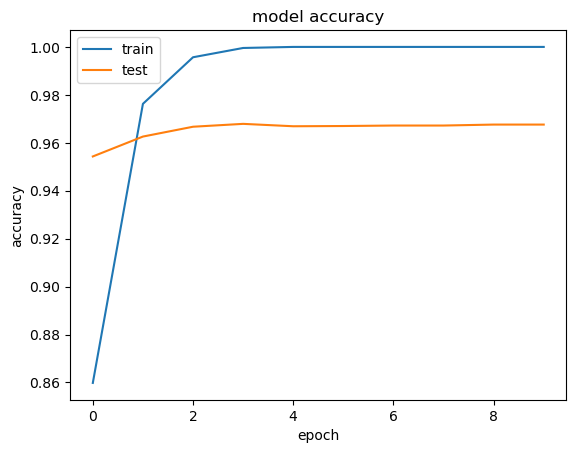

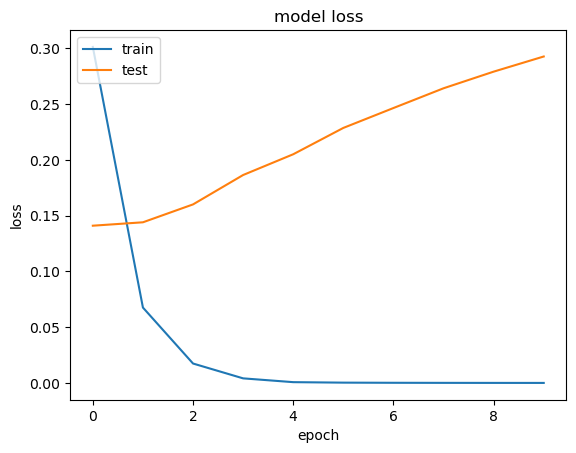

In [36]:
import matplotlib.pyplot as plt
%matplotlib inline 
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [37]:
y_pred = model.predict(x_test, verbose = 1)

313/313 [==============================] - 3s 11ms/step


In [38]:
y_pred

array([[1.0000000e+00],
       [6.9623327e-13],
       [1.0000000e+00],
       ...,
       [9.9999970e-01],
       [1.0000000e+00],
       [9.9999863e-01]], dtype=float32)

In [39]:
def fx(num):
    if num >= 0.5:
        return 1
    else:
        return 0

arr = np.asarray(list(map(fx,y_pred)))
ans = np.asarray(y_test)

In [40]:
f1 = f1_score(arr,ans, zero_division=1.0,average='weighted')
r1 = recall_score(arr,ans, zero_division=1.0,average='weighted')
p1 = precision_score(arr,ans, zero_division=1.0,average='weighted')
acc = accuracy_score(arr,ans)
print('f1',f1)
print('recall',r1)
print('precision',p1)
print('acc',acc)

f1 0.9730000302402372
recall 0.973
precision 0.9730003718421418
acc 0.973
